# Week 10 Demo: Preprocessing and Scaling

## Introduction

Weeks 2 through 8 covered supervised learning, the family of machine learning algorithms that learn from labeled examples. Every week, the workflow started the same way: you had a target column `y` (pass/fail, final score, churn, equipment failure), you split your data, you trained a model to predict that target, and you evaluated it by comparing predictions to known answers. The known answers were what made evaluation possible. The model always had something to learn toward.

**Chapter 3 introduces unsupervised learning**, where there is no target column. The algorithm receives only `X` (the features) and is asked to find structure in the data without any labels to guide it or check against. This changes what these algorithms can do and how you evaluate whether they did it well. Later in Chapter 3, you will work with dimensionality reduction (finding compact representations of high-dimensional data) and clustering (grouping similar data points together). Both are fully unsupervised: no `y`, no right answers to score against.

This week starts somewhere more familiar: **preprocessing**.

### What is preprocessing?

When you collect data in the real world, it rarely arrives in a form that machine learning algorithms can use directly. Features might be measured in different units, span wildly different numeric ranges, or contain values that create problems for specific algorithms. **Preprocessing** refers to any transformation applied to raw data to prepare it for modeling. It is not a learning step. Preprocessing does not teach the model anything. It is preparation work that happens before training begins, and its goal is to put the data in a form where the algorithm can work with it effectively.

Preprocessing is technically unsupervised because it only looks at `X`. There is no target column involved. A preprocessing step does not know whether a wine sample is class_0 or class_1. It only looks at the feature values themselves and applies a mathematical transformation to them.

Preprocessing covers a broad range of possible transformations. This demo focuses on one specific type: **scaling**.

### What is scaling, and why does it matter?

Consider how the features in a dataset are measured. In a medical dataset, one feature might measure a patient's age in years (typically 20 to 80), another might measure blood pressure in mmHg (typically 60 to 180), and another might measure a protein concentration in nanograms per milliliter (possibly 0.001 to 5.0). Each feature is measured in completely different units with completely different numeric ranges. The raw numbers do not reflect how important each feature is; they just reflect how each thing happens to be measured.

This creates a problem for machine learning algorithms that perform calculations across features. When an algorithm computes a distance between two data points, or optimizes a set of weights, the numeric scale of each feature directly affects how much that feature influences the result. A feature measured in the thousands will have a much larger arithmetic effect than a feature measured in fractions, even if the smaller feature contains equally useful information.

**Scaling** adjusts the numeric range of features so that each feature contributes proportionally to calculations, regardless of its original units or range. A scaler does not change the relationships between data points or add new information. It changes the representation of the data so that no single feature dominates purely because of the scale it was measured at.

Two scalers are covered in this demo:

- `StandardScaler` transforms each feature so that the values in that column have a mean of 0 and a standard deviation of 1. After transformation, every feature is centered at zero with the same spread, regardless of its original range.
- `MinMaxScaler` transforms each feature so that all values fall between 0 and 1. The smallest value in a column becomes 0, the largest becomes 1, and everything else scales proportionally in between.

Both scalers solve the same core problem through different mathematical transformations. The demo demonstrates both and compares their results.

Scaling is also the entry point into Chapter 3 for a practical reason: even though scaling is technically an unsupervised operation, it is almost always used alongside supervised models. You will apply a scaler to your features, then train a kNN classifier on the scaled data using the supervised workflow you already know. This makes scaling a natural bridge between what you have done and what comes next.

### What This Demo Covers

This demo covers:

- Why feature scaling matters and what goes wrong without it
- `StandardScaler`, which transforms features so each has a mean of 0 and a standard deviation of 1
- `MinMaxScaler`, which transforms features so each falls between 0 and 1
- The fit-on-training rule, the most important habit when using any scaler

The textbook then shows you:

- `RobustScaler`, a variant that uses the median and quartiles, making it resistant to outliers
- `Normalizer`, a fundamentally different kind of scaling that operates on rows rather than columns
- How scaling dramatically improves SVM accuracy on the cancer dataset
- A deeper discussion of what goes wrong when the fit-on-training rule is broken

## Part 1: Loading the Wine Dataset

This demo uses the Wine dataset, a built-in scikit-learn dataset containing 178 wine samples described by 13 chemical measurements. Each sample belongs to one of three classes, representing three different cultivars of wine from the same region in Italy.

The wine dataset is a good choice for this demo because its 13 features span dramatically different numeric ranges, which makes the effect of scaling easy to see and measure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load the wine dataset
wine = load_wine()

# Put features into a DataFrame for easy inspection
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["wine_class"] = wine.target

print(f"Dataset shape: {wine.data.shape}")
print(f"Number of classes: {len(wine.target_names)}")
print(f"Class names: {wine.target_names}")
print(f"\nClass distribution:")
for i, name in enumerate(wine.target_names):
    print(f"  {name}: {np.sum(wine.target == i)} samples")

df.head()

Dataset shape: (178, 13)
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']

Class distribution:
  class_0: 59 samples
  class_1: 71 samples
  class_2: 48 samples


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Understanding the code:**

**`load_wine()`:**
- This is a built-in scikit-learn dataset loader, imported from `sklearn.datasets`, the same module where `load_breast_cancer()` lives, which you saw referenced in the textbook.
- It returns a Bunch object with `.data` (the feature array), `.target` (the class labels), `.feature_names` (column names), and `.target_names` (class labels as strings).
- The dataset has 178 samples, 13 features, and 3 classes (class_0, class_1, class_2), representing three wine cultivars.

**Building a DataFrame:**
- `pd.DataFrame(wine.data, columns=wine.feature_names)` places the numeric data into a table with readable column names. This is the same pattern used in prior weeks.

---

Now look at the feature ranges. This is the central observation that motivates everything in this demo.

In [2]:
# Show the range of each feature
print("Feature ranges in the Wine dataset:\n")
print(f"{'Feature':<35} {'Min':>8} {'Max':>8} {'Range':>8}")
print("-" * 63)
for col in wine.feature_names:
    col_min = df[col].min()
    col_max = df[col].max()
    col_range = col_max - col_min
    print(f"{col:<35} {col_min:>8.3f} {col_max:>8.3f} {col_range:>8.3f}")

Feature ranges in the Wine dataset:

Feature                                  Min      Max    Range
---------------------------------------------------------------
alcohol                               11.030   14.830    3.800
malic_acid                             0.740    5.800    5.060
ash                                    1.360    3.230    1.870
alcalinity_of_ash                     10.600   30.000   19.400
magnesium                             70.000  162.000   92.000
total_phenols                          0.980    3.880    2.900
flavanoids                             0.340    5.080    4.740
nonflavanoid_phenols                   0.130    0.660    0.530
proanthocyanins                        0.410    3.580    3.170
color_intensity                        1.280   13.000   11.720
hue                                    0.480    1.710    1.230
od280/od315_of_diluted_wines           1.270    4.000    2.730
proline                              278.000 1680.000 1402.000


**What this table shows:**

This is the scale problem made concrete. Scan down the Range column. `nonflavanoid_phenols` has a range of about 0.53. `proline` has a range of about 1,402. That is a difference of roughly 2,600 times between two features in the same dataset, describing the same wine samples.

Neither feature is wrong. Both are real chemical measurements. The difference in range says nothing about which feature is more useful for predicting wine class. It only reflects the units each chemical property happens to be measured in. But for any algorithm that computes distances between data points, this difference in range translates directly into a difference in influence. `proline` will dominate. Part 2 shows exactly what that costs in practice.

## Part 2: The Problem with Unscaled Features

Before applying any scaling, establish a baseline by training kNN on the raw, unscaled data.

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Prepare features and target
X = wine.data
y = wine.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples\n")

# Train kNN on unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)

print("kNN accuracy on unscaled data (n_neighbors=5):")
print(f"  Training accuracy: {knn_unscaled.score(X_train, y_train):.3f}")
print(f"  Test accuracy:     {knn_unscaled.score(X_test, y_test):.3f}")

Training set: 133 samples
Test set:     45 samples

kNN accuracy on unscaled data (n_neighbors=5):
  Training accuracy: 0.767
  Test accuracy:     0.711


**What this tells us:**

Training accuracy is 0.767 and test accuracy is 0.711. The split produces 133 training samples and 45 test samples. A model that correctly classifies about 71% of wine samples on new data is a weak result for a dataset with well-separated classes. To understand why, it helps to revisit how kNN actually makes decisions.

Recall from Week 2: kNN classifies a new data point by finding the `k` closest training points and taking a majority vote. "Closest" is measured using Euclidean distance, the straight-line distance between two points in feature space. For a data point with features `a` and `b`, the squared distance to another point is calculated as the sum of the squared differences across all features:

> squared distance = (a₁ - b₁)² + (a₂ - b₂)² + ... + (a₁₃ - b₁₃)²

Every feature contributes one term to this sum. But the size of that contribution depends entirely on the scale of the feature. Consider what happens with the wine data:

- A typical difference between two wine samples in `proline` might be 200 units. That contributes 200² = **40,000** to the squared distance.
- A typical difference in `nonflavanoid_phenols` might be 0.1 units. That contributes 0.1² = **0.01** to the squared distance.

`proline` contributes roughly four million times more to the distance calculation than `nonflavanoid_phenols`. In practice, when kNN searches for the five nearest neighbors, it is finding the five wines with the most similar proline values; the other twelve features contribute almost nothing. The model is not broken. It is doing the math correctly. The math just happens to be dominated by one feature's scale.

Notice that the train/test split uses `random_state=42`, the same habit from every supervised learning week. Even though the scaler is an unsupervised operation, the split is still needed because we will be training a supervised model (kNN) on top of the scaled data and evaluating it on held-out examples.

## Part 3: StandardScaler

`StandardScaler` is the most commonly used preprocessing method. It transforms each feature so that the values in that column have a **mean of 0** and a **standard deviation of 1**. This is sometimes called standardization or z-score normalization.

The **mean** is the average value of a column: the sum of all values divided by the count. The **standard deviation** measures how spread out the values are around that mean. A small standard deviation means values cluster tightly around the mean; a large standard deviation means they are spread widely. After StandardScaler transforms a feature, its mean is exactly 0 (the values are centered) and its standard deviation is exactly 1 (the spread is normalized to a common unit).

The formula for each value is: subtract the column mean, then divide by the column standard deviation. After this transformation, every feature is on the same statistical footing regardless of its original units or range.

In [4]:
from sklearn.preprocessing import StandardScaler

# Step 1: Create the scaler
scaler_standard = StandardScaler()

# Step 2: Fit the scaler on training data only
scaler_standard.fit(X_train)

# Step 3: Transform both training and test sets
X_train_standard = scaler_standard.transform(X_train)
X_test_standard  = scaler_standard.transform(X_test)

# Inspect the result on training data
df_scaled = pd.DataFrame(X_train_standard, columns=wine.feature_names)

print("Selected feature statistics after StandardScaler (training data):\n")
print(f"{'Feature':<35} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 71)
for col in ['proline', 'nonflavanoid_phenols', 'alcohol']:
    print(f"{col:<35} {df_scaled[col].mean():>8.4f} {df_scaled[col].std():>8.4f} "
          f"{df_scaled[col].min():>8.3f} {df_scaled[col].max():>8.3f}")

Selected feature statistics after StandardScaler (training data):

Feature                                 Mean      Std      Min      Max
-----------------------------------------------------------------------
proline                               0.0000   1.0038   -1.521    2.630
nonflavanoid_phenols                 -0.0000   1.0038   -1.847    2.345
alcohol                               0.0000   1.0038   -2.350    2.246


**Understanding the code:**

**Three-step pattern (the key workflow):**

Scaling in scikit-learn follows the same fit/transform pattern used by supervised models, but with one important difference.

`scaler_standard.fit(X_train)` calls the fit method. The scaler examines the training data and computes the mean and standard deviation for each feature. Notice that only `X_train` is passed. There is no `y_train`. This is what makes scaling unsupervised: it learns from the features alone.

`scaler_standard.transform(X_train)` applies the transformation to the training data using the means and standard deviations just computed.

`scaler_standard.transform(X_test)` applies the **same** transformation to the test data using the means and standard deviations from the training data. The test set is transformed, not re-fitted.

**Reading the output:**

After scaling, `proline` has a mean of approximately 0.0 and a standard deviation of approximately 1.0, and so does `nonflavanoid_phenols`, and so does `alcohol`. Every feature is now on the same scale. The original difference in range (1,402 vs. 0.53) no longer affects distance calculations.

---

Now retrain kNN on the scaled data.

In [5]:
# Train kNN on StandardScaler-transformed data
knn_standard = KNeighborsClassifier(n_neighbors=5)
knn_standard.fit(X_train_standard, y_train)

print("kNN accuracy after StandardScaler (n_neighbors=5):")
print(f"  Training accuracy: {knn_standard.score(X_train_standard, y_train):.3f}")
print(f"  Test accuracy:     {knn_standard.score(X_test_standard, y_test):.3f}")

kNN accuracy after StandardScaler (n_neighbors=5):
  Training accuracy: 0.977
  Test accuracy:     0.956


**What changed:**

Training accuracy is 0.977 and test accuracy jumped from 0.711 to 0.956. The model went from correctly classifying about 71% of test samples to correctly classifying about 96%. The data did not change. The algorithm did not change. The only difference is that features are now on a common scale, and kNN can use all 13 features effectively when computing distances.

## Part 4: MinMaxScaler

`MinMaxScaler` is an alternative that transforms each feature so that all values fall between **0 and 1**. It does this by subtracting the minimum value of each feature and dividing by the range (maximum minus minimum). After this transformation, the smallest value in each column becomes 0 and the largest becomes 1.

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Same three-step pattern
scaler_minmax = MinMaxScaler()
scaler_minmax.fit(X_train)
X_train_minmax = scaler_minmax.transform(X_train)
X_test_minmax  = scaler_minmax.transform(X_test)

# Inspect the result on training data
df_mm = pd.DataFrame(X_train_minmax, columns=wine.feature_names)

print("Selected feature ranges after MinMaxScaler (training data):\n")
print(f"{'Feature':<35} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col in ['proline', 'nonflavanoid_phenols', 'alcohol']:
    print(f"{col:<35} {df_mm[col].min():>8.3f} {df_mm[col].max():>8.3f}")

Selected feature ranges after MinMaxScaler (training data):

Feature                                  Min      Max
-------------------------------------------------------
proline                                0.000    1.000
nonflavanoid_phenols                   0.000    1.000
alcohol                                0.000    1.000


**StandardScaler vs. MinMaxScaler: what is different:**

Both scalers follow the same three-step fit/transform workflow. The difference is in what they compute during `fit` and what they produce during `transform`.

`StandardScaler` computes mean and standard deviation during fit. After transforming, features are centered at 0 with values typically between about -3 and +3, but there are no guaranteed minimum or maximum values.

`MinMaxScaler` computes minimum and maximum during fit. After transforming, training data features are guaranteed to fall between 0 and 1. The values are bounded, which some models and visualizations prefer.

---

In [7]:
# Train kNN on MinMaxScaler-transformed data
knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)

print("kNN accuracy after MinMaxScaler (n_neighbors=5):")
print(f"  Training accuracy: {knn_minmax.score(X_train_minmax, y_train):.3f}")
print(f"  Test accuracy:     {knn_minmax.score(X_test_minmax, y_test):.3f}")

kNN accuracy after MinMaxScaler (n_neighbors=5):
  Training accuracy: 0.977
  Test accuracy:     0.933


**What this shows:**

MinMaxScaler also produces a strong result: test accuracy of 0.933, compared to 0.956 for StandardScaler and 0.711 for no scaling at all. Both scalers solve the core problem. The choice between them depends on the algorithm and the data, and the textbook's preprocessing section gives guidance on when each is preferred.

## Part 5: The Fit-on-Training Rule

The three-step pattern used in Parts 3 and 4 (`fit` on training data, `transform` both sets) is not arbitrary. It enforces an important rule that must carry forward into every week of the course.

**The rule:** a scaler must be fit only on training data, then used to transform both the training set and the test set.

This rule exists because the test set represents new, unseen data. In a real deployment, you would not have access to future data when building your model. If you fit the scaler on the full dataset (training and test combined), you are using information about the test set to influence how the training data is prepared. This leaks test information into training and gives an overly optimistic view of how the model will perform on truly new data.

In [8]:
# Demonstrating the correct pattern explicitly

# CORRECT: fit on training data only
scaler = StandardScaler()
scaler.fit(X_train)                        # learns mean/std from training set only
X_train_scaled = scaler.transform(X_train) # applies training statistics to training set
X_test_scaled  = scaler.transform(X_test)  # applies the same training statistics to test set

print("Correct workflow:")
print(f"  Scaler fitted on: {X_train.shape[0]} training samples")
print(f"  Training set transformed using training mean/std")
print(f"  Test set transformed using the same training mean/std\n")

# The scaler stores what it learned during fit
print("What the scaler learned from training data (first 3 features):")
for i, name in enumerate(wine.feature_names[:3]):
    print(f"  {name:<20}: mean={scaler.mean_[i]:.3f}, std={np.sqrt(scaler.var_[i]):.3f}")

Correct workflow:
  Scaler fitted on: 133 training samples
  Training set transformed using training mean/std
  Test set transformed using the same training mean/std

What the scaler learned from training data (first 3 features):
  alcohol             : mean=12.973, std=0.827
  malic_acid          : mean=2.387, std=1.095
  ash                 : mean=2.362, std=0.280


**Understanding the code:**

`scaler.mean_` and `scaler.var_` are attributes that store what the scaler computed during `fit`. They reflect only the training data. When `transform` is called on the test set, these same training values are used; the test set is shifted and scaled using the training set's statistics, not its own.

This is the same mindset as train/test splitting for supervised models: you evaluate performance on data the model has not seen. The scaler follows the same principle: it should only learn from data the model has not seen.

---

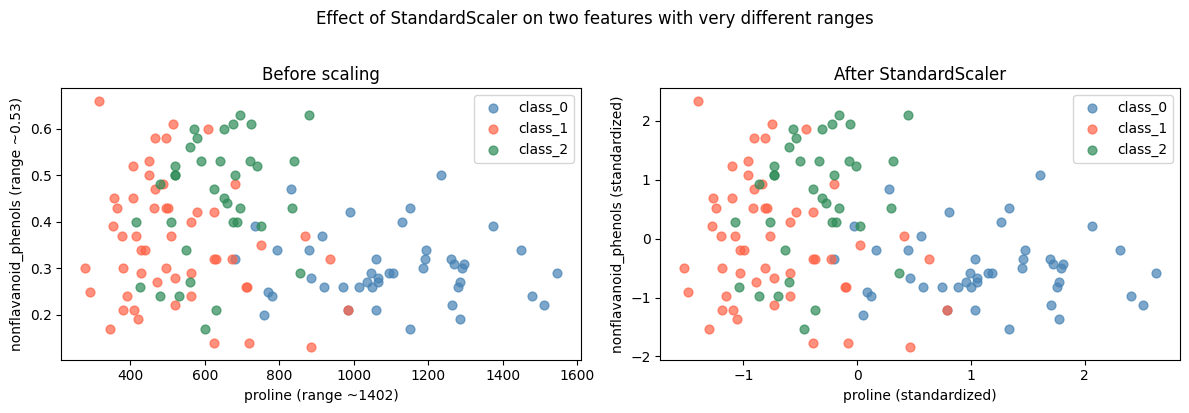

In [9]:
# Visualize the before/after effect for two features with very different scales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unscaled: proline vs nonflavanoid_phenols
colors = ['steelblue', 'tomato', 'seagreen']
for cls in range(3):
    mask = y_train == cls
    axes[0].scatter(
        X_train[mask, wine.feature_names.index('proline')],
        X_train[mask, wine.feature_names.index('nonflavanoid_phenols')],
        c=colors[cls], label=wine.target_names[cls], alpha=0.7, s=40
    )
axes[0].set_xlabel('proline (range ~1402)')
axes[0].set_ylabel('nonflavanoid_phenols (range ~0.53)')
axes[0].set_title('Before scaling')
axes[0].legend()

# Scaled
for cls in range(3):
    mask = y_train == cls
    axes[1].scatter(
        X_train_scaled[mask, wine.feature_names.index('proline')],
        X_train_scaled[mask, wine.feature_names.index('nonflavanoid_phenols')],
        c=colors[cls], label=wine.target_names[cls], alpha=0.7, s=40
    )
axes[1].set_xlabel('proline (standardized)')
axes[1].set_ylabel('nonflavanoid_phenols (standardized)')
axes[1].set_title('After StandardScaler')
axes[1].legend()

plt.suptitle('Effect of StandardScaler on two features with very different ranges', y=1.02)
plt.tight_layout()
plt.show()

**Reading the plots:**

The left plot shows the raw data. The x-axis (proline) spans from roughly 300 to 1,700. The y-axis (nonflavanoid_phenols) spans from 0.1 to 0.7. The data is extremely stretched horizontally; proline's scale pulls the plot wide while nonflavanoid_phenols contributes almost nothing to vertical spread.

The right plot shows the same data after StandardScaler. Both axes now have comparable ranges. The three wine classes separate more clearly, and kNN can use both features meaningfully when computing distances.

**Note on `wine.feature_names.index('proline')`:**

`wine.feature_names` is a Python list of feature name strings. The `.index()` method is a standard Python list method that returns the position of a value in the list. `wine.feature_names.index('proline')` returns the integer column position of `proline` in the feature array, which is needed to select that column from the NumPy array `X_train` using bracket indexing. This is the same as looking up a column by name in a DataFrame, but applied to a raw NumPy array where columns are accessed by integer position rather than name.

## Conclusion

### Key Takeaways

1. Feature scale affects distance-based algorithms. kNN computes distances between data points. When features have very different ranges, features with larger ranges dominate those distances. Scaling gives every feature a fair contribution.

2. `StandardScaler` centers each feature at mean 0 with standard deviation 1. It is the most common choice and works well for most distance-based algorithms.

3. `MinMaxScaler` compresses each feature to the range 0–1. It uses the minimum and maximum of the training data. Both scalers solve the same core problem through different transformations.

4. Scaling follows a three-step fit/transform pattern. `fit` learns statistics from the training data only. `transform` applies those statistics to both training and test sets. This is the same `fit`/`transform` pattern used by scikit-learn models, but with no `y`.

5. The fit-on-training rule is not optional. Fitting a scaler on the full dataset (including test data) leaks test information into training. Always fit the scaler on `X_train`, then transform both sets using the statistics learned from training.

6. Not all algorithms need scaling. Decision trees and ensemble methods like Random Forests make decisions by splitting on individual features at a time. The scale of features does not affect their splits. Algorithms that compute distances or optimize weights, such as kNN, linear models, SVMs, and neural networks, do benefit from scaling.

### Further Reading in the Textbook

As you read Chapter 3, pages 131–139, pay attention to:

1. **Figure 3-1 and the four scalers side by side**
   - The textbook shows all four scaling methods visually on a synthetic dataset, including `RobustScaler` and `Normalizer`, which this demo did not cover.

2. **`RobustScaler`**
   - Works like `StandardScaler` but uses the median and quartiles instead of mean and standard deviation. This makes it resistant to outliers, which can distort the mean and inflate the standard deviation.

3. **`Normalizer`**
   - Operates differently from the other three scalers. Instead of adjusting each column, it scales each individual row so that the feature vector for that sample has a length of 1. It is used when the direction of a data point matters more than its magnitude.

4. **The SVC accuracy example (pages 138–139)**
   - The textbook shows scaling applied before a Support Vector Machine on the cancer dataset. Unscaled accuracy is 0.63. Scaled accuracy is 0.97. This is the same principle demonstrated here with kNN and wine data, applied to a different algorithm and dataset.

5. **Figure 3-2 and what goes wrong when the rule is broken**
   - The textbook includes a visualization showing how scaling training and test sets separately distorts the spatial relationship between the two sets. This is worth studying carefully as a concrete illustration of why the fit-on-training rule matters.

The demo gave you the practical workflow and the clearest illustration of why scaling matters. The textbook provides the full picture: additional scalers, a deeper discussion of the fit-on-training rule, and the complete preprocessing section.